# STEP14. NITYMED 영상 단위 졸음 판별

## 분석 질문

- STEP12에서 선택한 Eye CNN으로 계산한 **PERCLOS · 최장 연속 감김**이 microsleep과 대조군(하품) 영상을 구분하는지 평가한다.
- 영상 단위 AUC를 비교하고, 영상 길이가 결과에 미치는 영향을 함께 확인한다.
- **H2: 눈 감김 지표만으로 microsleep과 하품을 구분할 수 있는가?**

## 왜 이 STEP 이 필요한가

STEP10~13 의 결과는 전부 DMD 기반이고, DMD 는 16영상 모두 `setup = Car Stopped` 다. 지금까지 검증한 것은 **연출된 눈 감김을 검출하는 능력**이지 **실제 졸음을 구분하는 능력**이 아니다.

NITYMED 는 이 프로젝트에서 **microsleep 라벨이 있는 유일한 데이터**다. 라벨 단위는 프레임이 아니라 영상이므로, 프레임 분류 성능이 아니라 영상 단위 판별력을 잰다.

## 입력

| 구분 | 경로 | 규모 |
|---|---|---|
| NITYMED 원본 영상 | `build_dmd_eye_dataset.data_subdir("NITYMED")` | microsleep 19 / 대조군 107 |
| 학습된 Eye CNN + 임계값 | `config.ARTIFACT_DIR / "eye_<tag>.keras"` · `..._metrics.json` (STEP12) | |
| YuNet 모델 | `config.YUNET_MODEL` | |

## 출력

| 파일 | 위치 |
|---|---|
| `video_metrics.csv` | `config.OUTPUTS_DIR / "nitymed_eval"` |
| `roc_curves.png` | `config.OUTPUTS_DIR / "nitymed_eval"` |
| `auc_summary.csv` | `config.OUTPUTS_DIR / "nitymed_eval"` |

## 전체 수행 흐름

**PART A — 준비**

1. 설정 · 모델 · 임계값 로드
2. 영상 목록과 표본 구성
3. 추론 함수 정의 + 한 영상 시범
3b. 축소 검출 타당성 점검

**PART B — 영상 단위 추론**

4. 영상 단위 추론
5. 클래스별 요약
5b. 영상 길이 교란 진단

**PART C — 판별력 평가**

6. ROC · AUC
7. 임계 0.15 에서의 민감도 · 특이도

## PART A — 준비

### 목적

- STEP12 가 고른 모델과 임계값을 그대로 가져온다. 여기서 다시 고르지 않는다.
- 영상 목록을 만들고 균형 표본을 정한다.

In [5]:
# [셀 1] 설정 · 모델 · 임계값 (import·경로·시드는 여기서 한 번만)

# --- 저장소 루트 부트스트랩 (모든 노트북 공통, 수정 금지) ---
import sys
from pathlib import Path

_anchors = []
if "__vsc_ipynb_file__" in globals():          # VS Code Notebook
    _anchors.append(Path(globals()["__vsc_ipynb_file__"]).resolve().parent)
if globals().get("_dh"):                        # IPython 커널 시작 폴더
    _anchors.append(Path(globals()["_dh"][0]).resolve())
_anchors.append(Path.cwd().resolve())           # 최후 수단

_root = next(
    (p for a in _anchors for p in [a, *a.parents]
     if (p / "config.py").is_file() and (p / "requirements.txt").is_file()),
    None,
)
if _root is not None:
    if str(_root) in sys.path:
        sys.path.remove(str(_root))
    sys.path.insert(0, str(_root))

import config

if _root is not None and Path(config.__file__).resolve().parent != _root:
    raise ImportError(f"의도하지 않은 config.py 가 import 되었습니다: {config.__file__}")
# --- 부트스트랩 끝 ---

_src = str(config.PROJECT_ROOT / "src")
if _src not in sys.path:
    sys.path.insert(0, _src)

import json
import time

import cv2
import numpy as np
import pandas as pd
import tensorflow as tf

import build_dmd_eye_dataset as B
from eye_preprocess import preprocess_eye

# STEP12 비교표에서 고른 조건. 바꾸려면 tag 만 교체한다.
MODEL_TAG = "mrl+dmd__eval-dmd__gray128"

SIZE, GRAY = 128, True          # MODEL_TAG 와 반드시 일치해야 한다
STRIDE = 5                       # 프레임 샘플링. PERCLOS 시간 해상도를 정한다
DETECT_WIDTH = None              # None 이면 원본 1280 에서 검출. 셀 3b 확인 후 640 으로 낮출 수 있다
SEED = 42

OUT_DIR = config.OUTPUTS_DIR / "nitymed_eval"
OUT_DIR.mkdir(parents=True, exist_ok=True)

_model_path = config.ARTIFACT_DIR / f"eye_{MODEL_TAG}.keras"
_metrics_path = config.ARTIFACT_DIR / f"eye_{MODEL_TAG}_metrics.json"
for _p in (_model_path, _metrics_path):
    if not _p.exists():
        raise FileNotFoundError(f"{config._rel(_p)} 가 없습니다. STEP12 를 먼저 실행하세요.")

_meta = json.loads(_metrics_path.read_text(encoding="utf-8"))
THRESHOLD = float(_meta["threshold"])     # STEP12 가 val 에서 고른 값

eye_model = tf.keras.models.load_model(_model_path)
if tuple(eye_model.input_shape[1:]) != (SIZE, SIZE, 1 if GRAY else 3):
    raise ValueError(f"모델 입력 {eye_model.input_shape} 와 SIZE/GRAY 설정이 다릅니다.")

detector = B.YuNetDetector()               # STEP02·13 과 같은 설정

print("모델   :", config._rel(_model_path))
print("임계값  :", round(THRESHOLD, 4), "(STEP12 val 에서 결정)")
print("DMD test 성능 :", {k: _meta["test_main"][k]
                          for k in ("closed_recall", "closed_precision", "closed_f1")})
print("stride :", STRIDE)

모델   : model\artifacts\eye_mrl+dmd__eval-dmd__gray128.keras
임계값  : 0.93 (STEP12 val 에서 결정)
DMD test 성능 : {'closed_recall': 0.9138, 'closed_precision': 0.7871, 'closed_f1': 0.8457}
stride : 5


### 결정 박스 11 — 대조군을 무엇으로 둘 것인가

- 문제: NITYMED 에는 microsleep 영상 19개와 하품 영상 107개만 있다. 음성 대조군으로 쓸 "정상 주행" 영상이 없다.
- 선택: **하품 영상을 대조군(음성)으로 쓴다.** 다만 결과를 "졸음 검출 성공/실패"로 읽지 않는다.
- 근거: 다른 음성 클래스가 없다. 하품 중에도 눈을 감으므로 대조군의 PERCLOS 가 0 이 아닐 수 있고, 그만큼 AUC 가 낮게 나올 수 있다. **AUC 가 낮게 나오면 그것은 실패가 아니라 "눈 지표만으로는 졸음과 하품이 분리되지 않는다"는 관찰이며, 위험도 지수에 하품 지표를 따로 두어야 하는 근거가 된다.**
- 하품 검출 자체는 이 노트북의 대상이 아니다(STEP20·21, 팀원 담당). 여기서는 영상 라벨만 쓴다.
- 사전 계획.

### 결정 박스 12 — 표본을 어떻게 구성할 것인가

- 문제: 19 대 107 로 불균형하다. 전체를 돌리면 126영상 약 41만 프레임이라 비용이 크다.
- 선택: **1단계는 균형 표본(19 + 19), 2단계는 전체.** 대조군 19개는 성별 비율을 유지해 뽑는다.
- 근거: AUC 는 불균형에 비교적 강하지만, 1단계에서 방향을 먼저 확인하고 전체를 돌리는 편이 시간을 아낀다. 전체 결과가 나오면 그것을 본 결과로 삼는다.
- 사전 계획.

In [6]:
# [셀 2] 영상 목록과 표본 구성
NITYMED_ROOT = B.data_subdir("NITYMED") / "DSM_Dataset-HDTV720"

rows = []
for p in sorted(NITYMED_ROOT.glob("*/*/HDTV720/*.mp4")):
    cls, gender = p.parts[-4], p.parts[-3]
    rows.append(dict(video=p.stem, cls=cls, gender=gender,
                     label=int(cls == "Microsleep"),   # microsleep = 양성
                     path=str(p)))
videos = pd.DataFrame(rows)
if videos.empty:
    raise FileNotFoundError(f"영상을 찾지 못했습니다: {config._rel(NITYMED_ROOT)}")

print(videos.groupby(["cls", "gender"]).size().rename("n").reset_index().to_string(index=False))

# 균형 표본: 양성 전부 + 음성에서 성별 비율 유지해 같은 수만큼.
# groupby().apply() 는 pandas 2.2+ 에서 그룹 컬럼을 떨어뜨린다(include_groups 경고).
# 인덱스만 모아 원본에서 뽑으면 컬럼이 그대로 남는다.
_pos = videos[videos.label == 1]
_neg = videos[videos.label == 0]
_keep = []
for _g, _grp in _neg.groupby("gender"):
    _keep.extend(_grp.sample(round(len(_pos) * len(_grp) / len(_neg)),
                             random_state=SEED).index)
_take = _neg.loc[sorted(_keep)]
balanced = pd.concat([_pos, _take]).reset_index(drop=True)

print(f"\n균형 표본 {len(balanced)}개")
print(balanced.groupby(["cls", "gender"]).size().rename("n").reset_index().to_string(index=False))

       cls gender  n
Microsleep Female  8
Microsleep   Male 11
   Yawning Female 59
   Yawning   Male 48

균형 표본 38개
       cls gender  n
Microsleep Female  8
Microsleep   Male 11
   Yawning Female 10
   Yawning   Male  9


### 목적

- 영상 1개로 검출률과 처리 속도를 재서 전체 실행 시간을 예상한다.
- DMD 와 달리 mosaic 타일 크롭이 없다. 전체 프레임에서 얼굴을 찾는다.

In [7]:
# [셀 3] 영상 단위 추론 함수 + 한 영상 시범
def detect_face_scaled(frame, detect_width=None):
    """얼굴 검출. detect_width 를 주면 축소본에서 검출하고 좌표를 원본으로 되돌린다.

    crop 은 항상 원본 프레임에서 뜬다. 축소본에서 crop 하면 눈 이미지가 뭉개진다.
    STEP02 의 detect_width 옵션과 같은 방식이다.
    """
    h, w = frame.shape[:2]
    if not detect_width or detect_width >= w:
        return detector.detect_face(frame)
    s = detect_width / w
    f = detector.detect_face(cv2.resize(frame, (detect_width, int(round(h * s)))))
    if f is None:
        return None
    f = f.copy()
    f[:14] = f[:14] / s              # box(0:4)·키포인트(4:14) 를 원본 좌표로. f[14]=score 는 그대로
    return f


def infer_nitymed(path, stride=STRIDE, max_frames=None, detect_width=None):
    """영상 하나를 프레임 단위로 추론하고 영상 단위 지표를 낸다.

    반환: (지표 dict, 프레임 DataFrame)
      검출 실패 프레임은 p_closed 를 NaN 으로 두고 분모에서 뺀다(STEP13 결정 박스 10).
      PERCLOS·최장 감김은 프레임 수가 아니라 시간(초)으로 잰다. fps 가 영상마다
      다를 수 있어 프레임으로 세면 영상 간 비교가 깨진다.
    """
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise FileNotFoundError(f"영상을 열 수 없습니다: {Path(path).name}")
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    step = stride / fps                       # 표본 1개가 대표하는 시간(초)

    probs, i = [], -1
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        i += 1
        if stride > 1 and (i % stride):
            continue
        if max_frames and len(probs) >= max_frames:
            break

        f = detect_face_scaled(frame, detect_width)
        p = np.nan
        if f is not None:
            res = detector.eye_crops(frame, f)
            if res is not None:
                crops, _ = res
                batch = np.stack([preprocess_eye(cr, size=SIZE, grayscale=GRAY,
                                                 do_sharpen=False, input_is_bgr=True)
                                  for _s, cr in crops])
                p = float(eye_model(batch, training=False).numpy()[:, 0].max())
        probs.append(p)
    cap.release()

    arr = np.array(probs, dtype=float)
    face_ok = ~np.isnan(arr)
    closed = np.zeros(len(arr), dtype=bool)
    closed[face_ok] = arr[face_ok] >= THRESHOLD

    # 최장 연속 Closed (초). 검출 실패 구간은 연속을 끊는다.
    best = cur = 0
    for ok_i, cl_i in zip(face_ok, closed):
        cur = cur + 1 if (ok_i and cl_i) else 0
        best = max(best, cur)

    n_face = int(face_ok.sum())
    m = dict(
        n_sampled=len(arr), n_judged=n_face,
        duration_sec=round(len(arr) * step, 1),
        coverage=round(n_face / len(arr), 4) if len(arr) else 0.0,
        perclos=round(int(closed.sum()) / n_face, 4) if n_face else np.nan,
        max_closure_sec=round(best * step, 2),
        mean_p_closed=round(float(np.nanmean(arr)), 4) if n_face else np.nan,
        fps=round(fps, 1),
    )
    return m, pd.DataFrame(dict(idx=np.arange(len(arr)) * step,
                                p_closed=arr, face_ok=face_ok, closed=closed))


_demo_row = balanced[balanced.label == 1].iloc[0]
_t0 = time.perf_counter()
_m, _d = infer_nitymed(_demo_row.path, max_frames=200, detect_width=DETECT_WIDTH)
_dt = time.perf_counter() - _t0

print("영상 :", _demo_row.video, f"({_demo_row.cls})")
print(f"처리 : {len(_d)} 프레임 / {_dt:.1f}s  ({len(_d)/_dt:.1f} frame/s)")
print("지표 :", _m)

영상 : P1042787_720 (Microsleep)
처리 : 200 프레임 / 20.0s  (10.0 frame/s)
지표 : {'n_sampled': 200, 'n_judged': 197, 'duration_sec': 40.0, 'coverage': 0.985, 'perclos': 0.0609, 'max_closure_sec': 0.6, 'mean_p_closed': 0.5397, 'fps': 25.0}


### 관찰 결과

- 처리 속도와 얼굴 검출 성공률(`coverage`)을 위 출력으로 확인한다.
- 전체 예상 시간 = 영상당 프레임 수 ÷ stride × 영상 수 ÷ 처리 속도.

### 결정 박스 13 — 검출 해상도와 실행 시간의 교환

- 문제: 원본 1280x720 에서 검출하면 프레임당 약 74ms 다. 126영상 x 약 640표본이면 100분이 넘는다. 축소본에서 검출하면 640 은 21ms, 480 은 12ms 로 3~6배 빠르다.
- 측정: 두 영상 98프레임에서 원본 대비 눈 키포인트 좌표 오차를 재 보면 640 은 중앙 10.6px / p90 14.8px, 480 은 중앙 9.1px / p90 15.3px 다. 눈 crop 반경(약 36px) 대비로는 **중앙 29% · p90 41%** 로 작지 않다. 눈이 crop 안에는 들어오지만 중심에서 벗어난다.
- 선택: **기본값은 원본 해상도(`DETECT_WIDTH = None`).** 축소는 아래 셀에서 Closed 확률 일치도를 확인한 뒤에만 켠다.
- 근거: 좌표 오차가 실제 판정을 바꾸는지는 픽셀 오차만으로 알 수 없다. 속도를 위해 정확도를 확인 없이 내주지 않는다. 일치도가 높게 나오면 전체 실행에서 `DETECT_WIDTH = 640` 으로 바꿔 시간을 3배 이상 줄일 수 있다.
- 이 선택은 탐색적이다. 측정 결과에 따라 정한다.

In [4]:
# [셀 3b] 축소 검출 타당성 점검 — 켤지 말지를 수치로 정한다
CANDIDATE_WIDTHS = [640, 480]
N_CHECK = 60          # 영상 2개에서 각각 이만큼

def sample_frames(path, n, stride=7):
    cap = cv2.VideoCapture(str(path)); out = []; i = -1
    while len(out) < n:
        ok, fr = cap.read()
        if not ok:
            break
        i += 1
        if i % stride == 0:
            out.append(fr)
    cap.release()
    return out


def prob_of(frame, detect_width):
    """한 프레임의 Closed 확률. 검출 실패면 NaN."""
    f = detect_face_scaled(frame, detect_width)
    if f is None:
        return np.nan
    r = detector.eye_crops(frame, f)
    if r is None:
        return np.nan
    crops, _ = r
    b = np.stack([preprocess_eye(c, size=SIZE, grayscale=GRAY,
                                 do_sharpen=False, input_is_bgr=True) for _s, c in crops])
    return float(eye_model(b, training=False).numpy()[:, 0].max())


check_frames = []
for _lab in (1, 0):
    check_frames += sample_frames(balanced[balanced.label == _lab].iloc[0].path, N_CHECK)

base = np.array([prob_of(fr, None) for fr in check_frames])
rows = []
for dw in CANDIDATE_WIDTHS:
    cur = np.array([prob_of(fr, dw) for fr in check_frames])
    both = ~(np.isnan(base) | np.isnan(cur))
    agree = ((base[both] >= THRESHOLD) == (cur[both] >= THRESHOLD)).mean()
    rows.append(dict(detect_width=dw, n=int(both.sum()),
                     판정일치율=round(float(agree), 4),
                     확률_평균절대차=round(float(np.abs(base[both] - cur[both]).mean()), 4),
                     검출실패_원본=int(np.isnan(base).sum()), 검출실패_축소=int(np.isnan(cur).sum())))

print(f"점검 프레임 {len(check_frames)}개 (양성·음성 영상 각 {N_CHECK})")
print(pd.DataFrame(rows).to_string(index=False))
print("\n판정 일치율이 0.99 이상이면 DETECT_WIDTH 를 그 값으로 바꿔 전체 실행 시간을 줄여도 된다.")
print("그보다 낮으면 DETECT_WIDTH = None 을 유지한다.")

점검 프레임 120개 (양성·음성 영상 각 60)
 detect_width   n  판정일치율  확률_평균절대차  검출실패_원본  검출실패_축소
          640 118 0.8814    0.2205        2        1
          480 118 0.9068    0.2371        2        0

판정 일치율이 0.99 이상이면 DETECT_WIDTH 를 그 값으로 바꿔 전체 실행 시간을 줄여도 된다.
그보다 낮으면 DETECT_WIDTH = None 을 유지한다.


### 관찰 결과

- 축소 640 의 Closed 판정 일치율은 0.881, 480 은 0.907 로 둘 다 기준 0.99 에 못 미친다.
- 확률 평균절대차가 0.22 로 커서, 축소본 검출은 눈 crop 중심을 벗어나 다른 판정을 낳는다.
- `DETECT_WIDTH = None`(원본 해상도)을 유지한다. 속도를 위해 정확도를 내주지 않는다.

## PART B — 영상 단위 추론

### 목적

- 영상마다 PERCLOS · 최장 연속 감김 · coverage 를 계산해 표로 만든다.
- 균형 표본으로 방향을 먼저 확인하고, 필요하면 전체로 넓힌다.

In [6]:
# [셀 4] 영상 단위 추론  ※ 실행 시간이 긴 셀
RUN_ALL = True       # True 면 126개 전부. 먼저 False(균형 표본 38개)로 확인한다

targets = videos if RUN_ALL else balanced
print(f"대상 {len(targets)} / {len(videos)}개 영상"
      f"{' (전체)' if RUN_ALL else ' (균형 표본)'}\n")

recs = []
t_start = time.perf_counter()
for n, r in enumerate(targets.itertuples(), 1):
    t0 = time.perf_counter()
    m, _ = infer_nitymed(r.path, detect_width=DETECT_WIDTH)
    recs.append(dict(video=r.video, cls=r.cls, gender=r.gender, label=r.label, **m))
    print(f"[{n:3d}/{len(targets)}] {r.video:18s} {r.cls:11s} "
          f"PERCLOS {m['perclos']:.3f}  최장감김 {m['max_closure_sec']:5.2f}s  "
          f"coverage {m['coverage']:.2f}  ({time.perf_counter()-t0:.0f}s)")

vm = pd.DataFrame(recs)
vm.to_csv(OUT_DIR / "video_metrics.csv", index=False)
print(f"\n총 {time.perf_counter()-t_start:.0f}s | 저장 : "
      f"{config._rel(OUT_DIR / 'video_metrics.csv')}")

대상 126 / 126개 영상 (전체)

[  1/126] P1042787_720       Microsleep  PERCLOS 0.050  최장감김  0.60s  coverage 1.00  (53s)
[  2/126] P1043067_720       Microsleep  PERCLOS 0.188  최장감김  2.60s  coverage 1.00  (50s)
[  3/126] P1043068_720       Microsleep  PERCLOS 0.181  최장감김  2.00s  coverage 1.00  (55s)
[  4/126] P1043089_720       Microsleep  PERCLOS 0.387  최장감김  3.80s  coverage 0.99  (45s)
[  5/126] P1043106_720       Microsleep  PERCLOS 0.197  최장감김  1.40s  coverage 1.00  (42s)
[  6/126] P1043114_720       Microsleep  PERCLOS 0.029  최장감김  0.20s  coverage 1.00  (5s)
[  7/126] P1043115_720       Microsleep  PERCLOS 0.016  최장감김  0.60s  coverage 1.00  (42s)
[  8/126] P1043129_720       Microsleep  PERCLOS 0.045  최장감김  0.60s  coverage 1.00  (44s)
[  9/126] P1042751_720       Microsleep  PERCLOS 0.163  최장감김  1.40s  coverage 1.00  (46s)
[ 10/126] P1042756_720       Microsleep  PERCLOS 0.198  최장감김  2.20s  coverage 1.00  (47s)
[ 11/126] P1042757_720       Microsleep  PERCLOS 0.082  최장감김  1.00s  coverage 

In [11]:
# [셀 5] 클래스별 지표 요약

# vm이 메모리에 없으면 셀 4에서 저장한 결과를 다시 불러온다.
if "vm" not in globals():
    vm = pd.read_csv(OUT_DIR / "video_metrics.csv")
    print("저장된 video_metrics.csv를 불러왔습니다.")

summary = (vm.groupby("cls")
             .agg(videos=("video", "size"),
                  perclos_mean=("perclos", "mean"),
                  perclos_median=("perclos", "median"),
                  max_closure_mean=("max_closure_sec", "mean"),
                  max_closure_median=("max_closure_sec", "median"),
                  coverage_mean=("coverage", "mean"))
             .round(4))

print(summary.to_string())

print("\n=== coverage 가 낮은 영상 (검출 실패 많음) ===")
low = vm.nsmallest(5, "coverage")[
    ["video", "cls", "coverage", "perclos", "n_judged"]
]
print(low.to_string(index=False))
summary = (vm.groupby("cls")
             .agg(videos=("video", "size"),
                  perclos_mean=("perclos", "mean"), perclos_median=("perclos", "median"),
                  max_closure_mean=("max_closure_sec", "mean"),
                  max_closure_median=("max_closure_sec", "median"),
                  coverage_mean=("coverage", "mean"))
             .round(4))
print(summary.to_string())

print("\n=== coverage 가 낮은 영상 (검출 실패 많음) ===")
low = vm.nsmallest(5, "coverage")[["video", "cls", "coverage", "perclos", "n_judged"]]
print(low.to_string(index=False))

저장된 video_metrics.csv를 불러왔습니다.
            videos  perclos_mean  perclos_median  max_closure_mean  max_closure_median  coverage_mean
cls                                                                                                  
Microsleep      19        0.2090          0.1814            2.1474                 1.6         0.9965
Yawning        107        0.1682          0.1256            1.3519                 1.0         0.9969

=== coverage 가 낮은 영상 (검출 실패 많음) ===
       video        cls  coverage  perclos  n_judged
P1042776_720    Yawning    0.9430   0.4832       149
P1042775_720    Yawning    0.9524   0.1875       160
P1042773_720    Yawning    0.9596   0.3316       190
P1042777_720    Yawning    0.9647   0.3023       602
P1042772_720 Microsleep    0.9726   0.5149       604
            videos  perclos_mean  perclos_median  max_closure_mean  max_closure_median  coverage_mean
cls                                                                                                  
Mi

> 클래스별 지표 요약. microsleep 쪽 PERCLOS·최장 감김이 대조군보다 높지만, 아래 셀 5b 에서 이 차이가 눈이 아니라 영상 길이에서 온 것임을 확인한다.


### 관찰 결과

- PERCLOS 중앙값은 microsleep **0.181**, 대조군 **0.126**이었다.
- 최장 연속 감김 중앙값은 microsleep **1.6초**, 대조군 **1.0초**였다.
- 얼굴 검출 성공률(`coverage`)은 두 클래스 모두 **0.997**이었다.
- 다만 microsleep 영상이 대조군보다 길어, 지표 차이에 **영상 길이의 영향이 포함될 가능성**이 확인되었다.

### 결정 박스 14 — 영상 길이 교란을 어떻게 다룰 것인가

- 문제: microsleep 영상과 대조군 영상의 길이가 크게 다를 수 있다. `max_closure_sec` 는 관찰 시간이 길수록 우연히라도 커지므로, 지표가 눈 상태가 아니라 영상 길이를 재고 있을 위험이 있다.
- 선택: **길이만으로 얻는 AUC 와 길이 회귀 잔차의 AUC 를 함께 보고한다.** 길이 보정 후에도 판별력이 남는지로 눈 지표의 실제 기여를 판단한다.
- 근거: 원본 AUC 만 보고하면 길이 교란을 눈 성능으로 오인한다. 길이 자체의 AUC 가 높고 보정 후 지표 AUC 가 0.5 로 붕괴하면, 겉보기 판별력은 눈이 아니라 길이에서 온 것이다.
- 사후 진단이다(탐색적). 원래 계획에 없던 검사이며, 셀 5 결과에서 길이 차이를 발견하고 추가했다.

In [12]:
# [셀 5b] 영상 길이 교란 진단 — 판별력이 눈 때문인가 길이 때문인가
# max_closure(초)는 영상이 길수록 우연히라도 커진다. microsleep 영상이 대조군보다
# 길면, 지표가 눈이 아니라 길이를 재고 있을 수 있다. 이 셀은 재추론 없이 vm 만 쓴다.

def auc_ci(y, s):
    """Mann-Whitney AUC + Hanley-McNeil 95% CI. sklearn 불필요."""
    y = np.asarray(y, float); s = np.asarray(s, float)
    order = np.argsort(s, kind="mergesort")
    rank = np.empty(len(s)); rank[order] = np.arange(1, len(s) + 1)
    ss = s[order]; i = 0                                   # 동점은 평균 순위로
    while i < len(s):
        j = i
        while j + 1 < len(s) and ss[j + 1] == ss[i]:
            j += 1
        if j > i:
            rank[order[i:j + 1]] = rank[order[i:j + 1]].mean()
        i = j + 1
    n1, n2 = y.sum(), (1 - y).sum()
    a = (rank[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n2)
    q1, q2 = a / (2 - a), 2 * a * a / (1 + a)
    se = np.sqrt((a * (1 - a) + (n1 - 1) * (q1 - a * a)
                  + (n2 - 1) * (q2 - a * a)) / (n1 * n2))
    return a, max(0.0, a - 1.96 * se), min(1.0, a + 1.96 * se)


y = vm.label.values
IND_COLS = ["max_closure_sec", "mean_p_closed", "perclos"]

print("클래스별 영상 길이(초):")
print(vm.groupby("cls").duration_sec.agg(["median", "mean", "min", "max"]).round(1).to_string())

_a, _lo, _hi = auc_ci(y, vm.duration_sec.values)
print(f"\n[경고] 영상 길이만으로 AUC = {_a:.3f}  [{_lo:.3f}, {_hi:.3f}]")
print("       microsleep 영상이 대조군보다 길다는 것만으로 클래스가 거의 갈린다.")
print(f"       길이-max_closure 상관 {vm.duration_sec.corr(vm.max_closure_sec):.3f}")

# 길이 회귀 잔차의 AUC — 길이로 설명되는 부분을 뺀 뒤 남는 판별력
X = np.c_[np.ones(len(vm)), vm.duration_sec.values]
print("\n지표별 AUC  원본 → 길이보정 (길이 효과 제거 후):")
adj_rows = []
for col in IND_COLS:
    a0, lo0, hi0 = auc_ci(y, vm[col].values)
    b = np.linalg.lstsq(X, vm[col].values, rcond=None)[0]
    a1, lo1, hi1 = auc_ci(y, vm[col].values - X @ b)
    adj_rows.append(dict(indicator=col, auc_raw=round(a0, 3), auc_raw_lo=round(lo0, 3),
                         auc_len_adjusted=round(a1, 3), adj_lo=round(lo1, 3), adj_hi=round(hi1, 3)))
    print(f"  {col:16s} {a0:.3f} [{lo0:.3f},{hi0:.3f}]  →  {a1:.3f} [{lo1:.3f},{hi1:.3f}]"
          f"  {'유의' if lo1 > 0.5 else '무작위 포함'}")

pd.DataFrame(adj_rows).to_csv(OUT_DIR / "auc_length_adjusted.csv", index=False)
print("\n저장 :", config._rel(OUT_DIR / "auc_length_adjusted.csv"))

클래스별 영상 길이(초):
            median   mean   min    max
cls                                   
Microsleep   125.8  122.8  14.0  146.6
Yawning       28.2   33.0  14.8  132.0

[경고] 영상 길이만으로 AUC = 0.931  [0.851, 1.000]
       microsleep 영상이 대조군보다 길다는 것만으로 클래스가 거의 갈린다.
       길이-max_closure 상관 0.305

지표별 AUC  원본 → 길이보정 (길이 효과 제거 후):
  max_closure_sec  0.670 [0.528,0.812]  →  0.417 [0.283,0.550]  무작위 포함
  mean_p_closed    0.625 [0.481,0.768]  →  0.474 [0.334,0.613]  무작위 포함
  perclos          0.582 [0.438,0.726]  →  0.472 [0.333,0.612]  무작위 포함

저장 : outputs\nitymed_eval\auc_length_adjusted.csv


## PART C — 판별력 평가

### 목적

- 영상 단위 ROC·AUC 로 두 지표의 판별력을 비교한다.
- STEP13 에서 쓴 PERCLOS 경보 임계 0.15 를 그대로 적용했을 때의 민감도·특이도를 본다.

평가 대상 126개 영상 (microsleep 19 / 대조군 107)


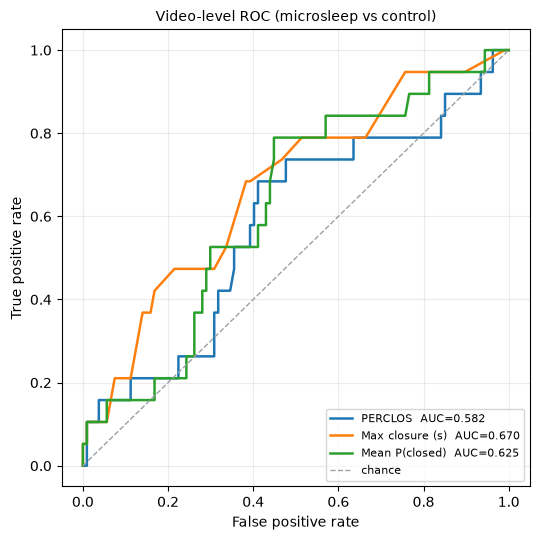

      indicator          column    auc   n  n_pos
Max closure (s) max_closure_sec 0.6699 126     19
 Mean P(closed)   mean_p_closed 0.6247 126     19
        PERCLOS         perclos 0.5821 126     19


In [ ]:
# [셀 6] ROC · AUC (영상 단위)
%pip install -r requirements.txt
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

INDICATORS = {
    "PERCLOS": "perclos",
    "Max closure (s)": "max_closure_sec",
    "Mean P(closed)": "mean_p_closed",
}

use = vm.dropna(subset=list(INDICATORS.values()))
y = use.label.values
print(f"평가 대상 {len(use)}개 영상 (microsleep {int(y.sum())} / 대조군 {int((1-y).sum())})")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
auc_rows = []
for name, col in INDICATORS.items():
    s = use[col].values
    auc = roc_auc_score(y, s)
    fpr, tpr, _ = roc_curve(y, s)
    ax.plot(fpr, tpr, lw=1.8, label=f"{name}  AUC={auc:.3f}")
    auc_rows.append(dict(indicator=name, column=col, auc=round(float(auc), 4),
                         n=len(use), n_pos=int(y.sum())))

ax.plot([0, 1], [0, 1], ls="--", lw=1, color="#9aa0a6", label="chance")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("Video-level ROC (microsleep vs control)", fontsize=10)
ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(OUT_DIR / "roc_curves.png", dpi=130); plt.show()

auc_df = pd.DataFrame(auc_rows).sort_values("auc", ascending=False)
auc_df.to_csv(OUT_DIR / "auc_summary.csv", index=False)
print(auc_df.to_string(index=False))

### 관찰 결과

- 원본 AUC는 최장 감김 **0.670**, 평균 Closed 확률 **0.625**, PERCLOS **0.582**였다.
- 최장 감김의 95% CI는 **[0.528, 0.812]**였으며, PERCLOS와 평균 Closed 확률의 CI는 0.5를 포함했다.
- 이 결과는 영상 길이 차이를 고려하기 전의 값이므로, **최종 판별 성능으로 해석하지 않는다.**

In [11]:
# [셀 7] 임계 0.15 에서의 민감도 · 특이도
# STEP13 에서 참고선으로 쓴 값을 그대로 적용해 본다. 이 프로젝트에서 검증한 임계는 아니다.
PERCLOS_ALERT = 0.15

pred = (use.perclos.values >= PERCLOS_ALERT).astype(int)
tp = int(((pred == 1) & (y == 1)).sum()); fn = int(((pred == 0) & (y == 1)).sum())
fp = int(((pred == 1) & (y == 0)).sum()); tn = int(((pred == 0) & (y == 0)).sum())

print(f"PERCLOS >= {PERCLOS_ALERT} 로 판정할 때")
print(f"  민감도(TPR) : {tp/(tp+fn):.4f}   ({tp}/{tp+fn})")
print(f"  특이도(TNR) : {tn/(tn+fp):.4f}   ({tn}/{tn+fp})")
print(f"  위양성률    : {fp/(fp+tn):.4f}")
print(f"\n  혼동행렬  실제 microsleep -> 경보 {tp} / 미경보 {fn}")
print(f"            실제 대조군     -> 경보 {fp} / 미경보 {tn}")

# 임계값을 옮기면 어떻게 되는지 (탐색적 — 이 값으로 결론을 내지 않는다)
print("\n=== PERCLOS 임계값 스윕 (탐색적) ===")
sweep = []
for t in np.arange(0.05, 0.61, 0.05):
    p = (use.perclos.values >= t).astype(int)
    _tp = int(((p == 1) & (y == 1)).sum()); _fn = int(((p == 0) & (y == 1)).sum())
    _fp = int(((p == 1) & (y == 0)).sum()); _tn = int(((p == 0) & (y == 0)).sum())
    sweep.append(dict(threshold=round(float(t), 2),
                      sensitivity=round(_tp/(_tp+_fn), 3) if _tp+_fn else np.nan,
                      specificity=round(_tn/(_tn+_fp), 3) if _tn+_fp else np.nan))
print(pd.DataFrame(sweep).to_string(index=False))

PERCLOS >= 0.15 로 판정할 때
  민감도(TPR) : 0.6842   (13/19)
  특이도(TNR) : 0.5607   (60/107)
  위양성률    : 0.4393

  혼동행렬  실제 microsleep -> 경보 13 / 미경보 6
            실제 대조군     -> 경보 47 / 미경보 60

=== PERCLOS 임계값 스윕 (탐색적) ===
 threshold  sensitivity  specificity
      0.05        0.842        0.159
      0.10        0.737        0.411
      0.15        0.684        0.561
      0.20        0.263        0.692
      0.25        0.263        0.776
      0.30        0.211        0.804
      0.35        0.211        0.860
      0.40        0.158        0.925
      0.45        0.158        0.963
      0.50        0.105        0.991
      0.55        0.053        0.991
      0.60        0.000        0.991


### 관찰 결과

- PERCLOS >= 0.15 로 판정하면 민감도 0.684(19명 중 13명), 특이도 0.561(107명 중 60명), 위양성률 0.44 다.
- 임계값 스윕에서 민감도와 특이도가 교차하는 지점은 약 0.13~0.15 이고, 그 지점의 두 값이 모두 0.6 근처다.
- 특이도를 0.9 로 올리면(임계 0.40) 민감도가 0.16 으로 떨어진다. 실용적 동작점이 없다.


## 해석

- microsleep 영상의 중앙 길이는 **126초**, 대조군은 **28초**로 차이가 컸다. 영상 길이만으로 계산한 AUC도 **0.931**로 높게 나타나, 원본 지표 AUC에 길이 효과가 포함되었을 가능성이 높다.
- 길이를 보정한 후 세 지표의 AUC는 **0.42~0.47**로 낮아졌다. 따라서 **원본 AUC만으로 눈 지표의 판별력을 평가하기는 어렵다.**
- 길이 보정 결과에서는 눈 지표의 독립적인 판별력이 명확하게 확인되지 않았다. H2는 **지지되지 않았다.**
- 이는 Eye CNN의 눈 감김 검출 성능 자체가 낮다는 의미가 아니라, **눈 감김이라는 단일 신호만으로 microsleep과 하품을 구분하는 데 한계가 있을 가능성**을 보여준다.

## 한계

- **영상 길이 차이**: microsleep 영상이 대조군보다 길어 원본 AUC에 길이 효과가 포함될 가능성이 있다.
- **대조군의 성격**: 음성 대조군은 정상 주행이 아니라 **Yawning** 영상이다. 따라서 결과를 일반적인 정상 대조군과의 졸음 판별 성능으로 해석할 수 없다.
- **표본 규모**: microsleep 영상은 19개로, AUC 신뢰구간이 넓다.
- **인물 정보 제한**: 파일명만으로는 동일 인물 여부를 확인할 수 없어 인물 단위 독립성을 완전히 검증하기 어렵다.
- **임계값**: 프레임 임계값 0.93은 DMD validation에서 선택한 값을 그대로 적용했으며, NITYMED에서 별도로 최적화하지 않았다.
- **PERCLOS 0.15**: 참고용 임계값이며 NITYMED에서 최적화한 값이 아니다.


### 길이 교란을 제거한 재분석

PART D 에서 슬라이딩 창으로 모든 영상을 같은 관찰 길이(20초)로 맞춰 다시 비교한다. 그 결과가 이 STEP 의 최종 판별력이다.

## PART D — 슬라이딩 창 재분석

### 목적

- 20초 관찰창을 사용해 영상 길이에 따른 직접적인 영향을 줄인 상태에서 다시 비교한다.
- 영상마다 창 지표를 하나로 요약하여 영상 단위 판별력을 평가한다.
- 창 개수 차이가 결과에 미치는 영향도 별도로 확인한다.

### 결정 박스 15 — 창 집계

- 문제: 긴 영상은 더 많은 window를 생성하므로 최댓값을 사용할 경우 창 개수에 따른 차이가 남을 수 있다.
- 선택: 영상별 창 지표의 최댓값을 사용하고, **창 개수의 영향은 D3에서 별도로 점검한다.**
- window = **20초**, hop = **10초**, coverage 50% 미만 창은 제외한다.
- 본 분석은 영상 길이 차이를 완화하기 위한 **추가 민감도 분석**이다.

### 목적

- 창 분석은 프레임 단위 확률이 있어야 한다. 셀 4 는 요약만 저장하고 프레임 확률은 버렸으므로, 균형 표본 38영상에 대해 프레임 확률을 저장하며 한 번 더 추론한다.
- 이후 창 분석(셀 D2·D3)은 저장된 프레임만 읽어 즉시 돌아간다. 창 길이를 바꿔도 재추론이 필요 없다.

In [13]:
# [셀 D1] 프레임 확률 저장하며 균형 표본 재추론  ※ 실행 시간이 긴 셀 (약 15~25분)
FRAMES_DIR = OUT_DIR / "frames"
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

t_start = time.perf_counter()
for n, r in enumerate(balanced.itertuples(), 1):
    fp = FRAMES_DIR / f"{r.video}.csv"
    if fp.exists():                       # 이미 저장된 영상은 건너뛴다(재실행 대비)
        continue
    t0 = time.perf_counter()
    _, fr = infer_nitymed(r.path, detect_width=DETECT_WIDTH)
    fr.to_csv(fp, index=False)
    print(f"[{n:2d}/{len(balanced)}] {r.video:18s} {r.cls:11s} "
          f"{len(fr)} 프레임 저장  ({time.perf_counter()-t0:.0f}s)")

print(f"\n총 {time.perf_counter()-t_start:.0f}s | 프레임 저장 위치: {config._rel(FRAMES_DIR)}")
print("저장된 영상:", len(list(FRAMES_DIR.glob('*.csv'))), "개")

[ 1/38] P1042787_720       Microsleep  658 프레임 저장  (68s)
[ 2/38] P1043067_720       Microsleep  657 프레임 저장  (51s)
[ 3/38] P1043068_720       Microsleep  733 프레임 저장  (56s)
[ 4/38] P1043089_720       Microsleep  624 프레임 저장  (46s)
[ 5/38] P1043106_720       Microsleep  620 프레임 저장  (49s)
[ 6/38] P1043114_720       Microsleep  70 프레임 저장  (6s)
[ 7/38] P1043115_720       Microsleep  611 프레임 저장  (44s)
[ 8/38] P1043129_720       Microsleep  619 프레임 저장  (45s)
[ 9/38] P1042751_720       Microsleep  643 프레임 저장  (47s)
[10/38] P1042756_720       Microsleep  620 프레임 저장  (46s)
[11/38] P1042757_720       Microsleep  730 프레임 저장  (54s)
[12/38] P1042762_720       Microsleep  619 프레임 저장  (49s)
[13/38] P1042767_720       Microsleep  646 프레임 저장  (48s)
[14/38] P1042772_720       Microsleep  621 프레임 저장  (46s)
[15/38] P1042786_720       Microsleep  655 프레임 저장  (52s)
[16/38] P1042793_720       Microsleep  629 프레임 저장  (51s)
[17/38] P1042797_720       Microsleep  629 프레임 저장  (53s)
[18/38] P1043075_720       Micros

In [14]:
# [셀 D2] 슬라이딩 창 지표 + 영상별 최댓값 요약 + AUC (재추론 없음)
WINDOW_SEC = 20.0        # 관찰 창 길이. 모든 영상 동일
HOP_SEC = 10.0           # 창 간격(50% 겹침)
MIN_COVERAGE = 0.5       # 창 내 얼굴 검출 비율이 이보다 낮으면 버린다

def sliding_window_scores(fr, window_sec, hop_sec, min_coverage=MIN_COVERAGE):
    """프레임 DataFrame(idx=초, p_closed, face_ok) -> 창별 지표 DataFrame."""
    idx = fr["idx"].values
    if len(idx) < 2:
        return pd.DataFrame()
    step = float(np.median(np.diff(idx)))          # 표본 간격(초)
    win = max(1, int(round(window_sec / step)))
    hop = max(1, int(round(hop_sec / step)))
    p = fr["p_closed"].values
    face = fr["face_ok"].values.astype(bool)
    closed = np.where(face, p >= THRESHOLD, False)
    rows, last = [], len(fr) - win
    starts = range(0, last + 1, hop) if last >= 0 else [0]   # 영상이 창보다 짧으면 통째로 1창
    for s in starts:
        sl = slice(s, s + win)
        wf, wc, wp = face[sl], closed[sl], p[sl]
        nf, span = int(wf.sum()), len(wf)
        if span == 0 or nf < span * min_coverage:
            continue
        best = cur = 0                              # 창 내 최장 연속 감김(초)
        for ok_i, cl_i in zip(wf, wc):
            cur = cur + 1 if (ok_i and cl_i) else 0
            best = max(best, cur)
        rows.append(dict(perclos=wc.sum() / nf, max_closure=best * step,
                         mean_p=float(np.nanmean(np.where(wf, wp, np.nan)))))
    return pd.DataFrame(rows)


recs = []
for r in balanced.itertuples():
    fp = FRAMES_DIR / f"{r.video}.csv"
    if not fp.exists():
        continue
    w = sliding_window_scores(pd.read_csv(fp), WINDOW_SEC, HOP_SEC)
    if w.empty:
        continue
    recs.append(dict(video=r.video, cls=r.cls, label=r.label, n_windows=len(w),
                     perclos=round(w.perclos.max(), 4),
                     max_closure=round(w.max_closure.max(), 2),
                     mean_p=round(w.mean_p.max(), 4)))    # 가장 눈 감은 창

wv = pd.DataFrame(recs)
wv.to_csv(OUT_DIR / "window_video_scores.csv", index=False)
print(f"창 요약 {len(wv)}개 영상 (window={WINDOW_SEC:.0f}s, hop={HOP_SEC:.0f}s)")
print(wv.groupby("cls")[["perclos", "max_closure", "mean_p", "n_windows"]].median().round(3).to_string())

y = wv.label.values
print("\n=== 길이 교란 제거 후 AUC (창 최댓값, 관찰 길이 동일) ===")
win_auc = []
for name, col in [("Max closure (s)", "max_closure"), ("Mean P(closed)", "mean_p"),
                  ("PERCLOS", "perclos")]:
    a, lo, hi = auc_ci(y, wv[col].values)     # auc_ci 는 셀 5b 정의
    win_auc.append(dict(indicator=name, column=col, auc=round(a, 3),
                        ci_lo=round(lo, 3), ci_hi=round(hi, 3),
                        significant=bool(lo > 0.5)))
    print(f"  {name:16s} AUC {a:.3f}  [{lo:.3f}, {hi:.3f}]  {'유의' if lo > 0.5 else '무작위 포함'}")
pd.DataFrame(win_auc).to_csv(OUT_DIR / "window_auc.csv", index=False)

창 요약 38개 영상 (window=20s, hop=10s)
            perclos  max_closure  mean_p  n_windows
cls                                                
Microsleep     0.27          1.6   0.557       11.0
Yawning        0.16          1.0   0.425        1.0

=== 길이 교란 제거 후 AUC (창 최댓값, 관찰 길이 동일) ===
  Max closure (s)  AUC 0.676  [0.504, 0.848]  유의
  Mean P(closed)   AUC 0.684  [0.514, 0.855]  유의
  PERCLOS          AUC 0.640  [0.463, 0.817]  무작위 포함


### 관찰 결과

- (실행 후 채운다) 창 요약 클래스별 중앙값(PERCLOS·최장 감김·창 개수).
- (실행 후 채운다) 길이 교란 제거 후 세 지표의 AUC 와 신뢰구간.
- (실행 후 채운다) 원본 AUC(셀 6)·길이보정 AUC(셀 5b)와 비교해 어느 쪽에 가까운지.

In [15]:
# [셀 D3] 극단값 편향 점검 — 창 개수를 통제해도 판별력이 남는가
# 창이 많을수록(=영상이 길수록) 최댓값이 우연히 커질 수 있다. 창 개수를 회귀로 뺀다.
X = np.c_[np.ones(len(wv)), wv.n_windows.values]
print("창 개수만으로 얻는 AUC :", end=" ")
a, lo, hi = auc_ci(y, wv.n_windows.values.astype(float))
print(f"{a:.3f} [{lo:.3f}, {hi:.3f}]  (0.5 에 가까울수록 창 개수 편향이 작다)")

print("\n지표별 AUC  원본 → 창개수 보정:")
for name, col in [("Max closure (s)", "max_closure"), ("Mean P(closed)", "mean_p"),
                  ("PERCLOS", "perclos")]:
    a0, lo0, hi0 = auc_ci(y, wv[col].values)
    b = np.linalg.lstsq(X, wv[col].values, rcond=None)[0]
    a1, lo1, hi1 = auc_ci(y, wv[col].values - X @ b)
    print(f"  {name:16s} {a0:.3f}[{lo0:.3f},{hi0:.3f}]  →  {a1:.3f}[{lo1:.3f},{hi1:.3f}]"
          f"  {'유의' if lo1 > 0.5 else '무작위 포함'}")

창 개수만으로 얻는 AUC : 0.945 [0.867, 1.000]  (0.5 에 가까울수록 창 개수 편향이 작다)

지표별 AUC  원본 → 창개수 보정:
  Max closure (s)  0.676[0.504,0.848]  →  0.406[0.224,0.588]  무작위 포함
  Mean P(closed)   0.684[0.514,0.855]  →  0.424[0.240,0.607]  무작위 포함
  PERCLOS          0.640[0.463,0.817]  →  0.402[0.220,0.583]  무작위 포함


## PART D — 슬라이딩 창 재분석

### 관찰 결과

- 20초 window, 10초 hop으로 분석한 결과, 창 개수만으로 얻은 AUC는 **0.945 [0.867, 1.000]** 이었다.
- 이는 microsleep 영상에서 관찰 가능한 window 수가 대조군보다 많다는 차이가 **영상 구분에 크게 기여할 수 있음**을 보여준다.
- 창 개수의 영향을 고려한 뒤 세 지표의 AUC는 다음과 같이 낮아졌다.

| 지표 | 원본 AUC | 창 개수 보정 AUC |
|---|---:|---:|
| Max closure (s) | 0.676 [0.504, 0.848] | **0.406 [0.224, 0.588]** |
| Mean P(closed) | 0.684 [0.514, 0.855] | **0.424 [0.240, 0.607]** |
| PERCLOS | 0.640 [0.463, 0.817] | **0.402 [0.220, 0.583]** |

- 창 개수 보정 후 세 지표의 95% 신뢰구간은 모두 **0.5를 포함**했다.

## PART D 해석

- 원본 영상에서 관찰된 눈 지표의 AUC는 창 개수의 영향을 함께 반영했을 가능성이 있다.
- 창 개수의 영향을 고려하면 세 지표의 AUC가 **0.402~0.424**로 낮아졌으며, 이 표본에서는 **microsleep과 하품을 구분하는 유의한 판별력을 확인하지 못했다.**
- 따라서 STEP14의 원본 AUC를 **눈 감김 지표 자체의 판별 성능으로 직접 해석하기 어렵다.**
- 특히 창 개수만으로도 AUC가 **0.945**로 나타났다는 점에서, 영상 길이 및 관찰량 차이가 결과에 상당한 영향을 줄 수 있음을 확인했다.

## STEP14 요약

### Takeaway

- 원본 영상 단위에서는 최장 감김 AUC **0.670**으로 일정 수준의 판별력이 관찰됐지만, microsleep과 대조군의 영상 길이가 크게 달랐다.
- 영상 길이만으로도 AUC **0.931**이 나타났고, 길이를 보정한 세 지표의 AUC는 **0.42~0.47**로 낮아졌다.
- 따라서 **원본 AUC를 눈 지표의 판별 성능으로 직접 해석하기 어렵다.**
- 길이 영향을 고려한 분석에서는 눈 지표의 독립적인 판별력이 명확하게 확인되지 않았으며, **H2는 지지되지 않았다.**
- 대조군이 정상 주행이 아닌 **Yawning**이라는 점을 고려하면, 이 결과는 일반적인 정상 대비 졸음 검출 성능으로 일반화하지 않는다.
- PART D에서는 20초 window 기반 분석으로 이 결과가 관찰 단위에 따라 달라지는지 추가 확인한다.